In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import joblib
import json
import matplotlib.pyplot as plt

# Check for MPS (Apple Silicon GPU) availability
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

Using MPS (Apple Silicon GPU)
Device: mps


In [17]:
# Load the dataset
df = pd.read_csv('../../data/alzheimers_disease_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (2149, 35)

First few rows:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check target distribution
print("\nTarget distribution:")
print(df['Diagnosis'].value_counts())

Missing values:
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTas

In [18]:
# Drop identifier columns before encoding
df = df.drop(columns=['PatientID', 'DoctorInCharge'])

# Convert categorical variables to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Encoded dataset shape: {df_encoded.shape}")
print(f"Features: {df_encoded.columns.tolist()}")

Encoded dataset shape: (2149, 33)
Features: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


In [19]:
# Split features and target
X = df_encoded.drop(columns=['Diagnosis'])
y = df_encoded['Diagnosis']

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature shape: (2149, 32)
Target shape: (2149,)


In [20]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")

Training set: (1719, 32)
Test set: (430, 32)

Train target distribution: {0: 1111, 1: 608}
Test target distribution: {0: 278, 1: 152}


In [21]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

Scaled training data shape: (1719, 32)
Mean: -0.0000, Std: 1.0000


In [22]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 54
Number of test batches: 14


## Define Neural Network Architecture

In [23]:
class AlzheimerNet(nn.Module):
    def __init__(self, input_dim):
        super(AlzheimerNet, self).__init__()
        
        self.network = nn.Sequential(
            # First hidden layer
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Second hidden layer
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Third hidden layer
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Output layer
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
input_dim = X_train_scaled.shape[1]
model = AlzheimerNet(input_dim).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

AlzheimerNet(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Total parameters: 5281


In [24]:
# Calculate class weights for balanced training
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to tensor
pos_weight = torch.FloatTensor([class_weights[1] / class_weights[0]]).to(device)

print(f"Class weights: {class_weights}")
print(f"Positive weight for loss: {pos_weight.item():.4f}")

Class weights: [0.77362736 1.41365132]
Positive weight for loss: 1.8273


In [25]:
# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"Optimizer: {optimizer}")
print(f"Loss function: {criterion}")

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Loss function: BCELoss()


## Train the Model

In [26]:
# Training loop
num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        predictions = (outputs > 0.5).float()
        train_correct += (predictions == y_batch).sum().item()
        train_total += y_batch.size(0)
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            
            predictions = (outputs > 0.5).float()
            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
        print(f'  LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print('\nTraining completed!')
print(f'Best validation loss: {best_val_loss:.4f}')

Epoch [5/50]
  Train Loss: 0.3976, Train Acc: 0.8377
  Val Loss: 0.4055, Val Acc: 0.8326
  LR: 0.001000
Epoch [10/50]
  Train Loss: 0.3393, Train Acc: 0.8668
  Val Loss: 0.3981, Val Acc: 0.8326
  LR: 0.001000
Epoch [15/50]
  Train Loss: 0.3046, Train Acc: 0.8778
  Val Loss: 0.3835, Val Acc: 0.8512
  LR: 0.001000
Epoch [20/50]
  Train Loss: 0.2646, Train Acc: 0.8988
  Val Loss: 0.3931, Val Acc: 0.8488
  LR: 0.001000

Early stopping at epoch 22

Training completed!
Best validation loss: 0.3752


## Model Evaluation

In [27]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Make predictions on test set
with torch.no_grad():
    y_pred_prob = model(X_test_tensor).squeeze().cpu().numpy()
    y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

Final Test Accuracy: 84.65%
ROC-AUC Score: 0.8999

Confusion Matrix:
[[247  31]
 [ 35 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       278
           1       0.79      0.77      0.78       152

    accuracy                           0.85       430
   macro avg       0.83      0.83      0.83       430
weighted avg       0.85      0.85      0.85       430



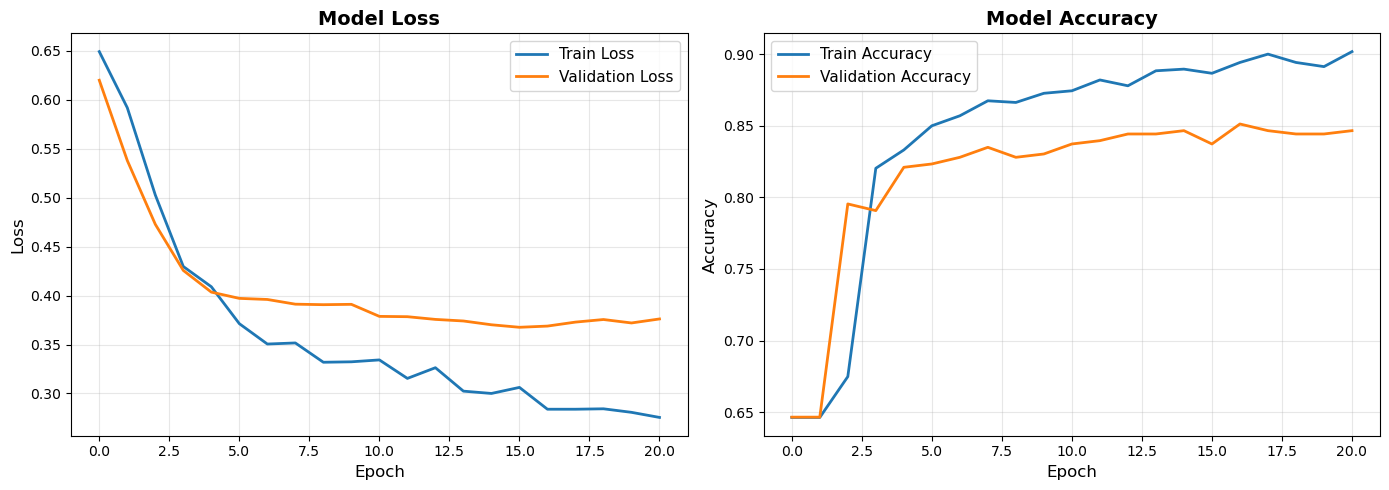

In [14]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Model Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', linewidth=2)
ax2.plot(val_accuracies, label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Model and Artifacts

In [28]:
# Save the model (best weights already saved)
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': input_dim,
    'optimizer_state_dict': optimizer.state_dict(),
}, 'pytorch_nn_model.pth')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save metrics
metrics = {
    'accuracy': float(accuracy),
    'roc_auc': float(roc_auc),
    'confusion_matrix': cm.tolist(),
    'final_train_loss': float(train_losses[-1]),
    'final_val_loss': float(val_losses[-1]),
    'best_val_loss': float(best_val_loss),
    'epochs_trained': len(train_losses)
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("✅ Model saved as 'pytorch_nn_model.pth'")
print("✅ Scaler saved as 'scaler.pkl'")
print("✅ Metrics saved as 'metrics.json'")
print("\nModel is ready for deployment!")

✅ Model saved as 'pytorch_nn_model.pth'
✅ Scaler saved as 'scaler.pkl'
✅ Metrics saved as 'metrics.json'

Model is ready for deployment!


In [16]:
# Test loading the model
test_model = AlzheimerNet(input_dim).to(device)
checkpoint = torch.load('pytorch_nn_model.pth')
test_model.load_state_dict(checkpoint['model_state_dict'])
test_model.eval()

print("✅ Model loaded successfully!")
print(f"Input dimension: {checkpoint['input_dim']}")

✅ Model loaded successfully!
Input dimension: 32
